In [2]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from itertools import combinations
from math import factorial

In [7]:
def make_sigma(p, rho):
    """Construct Sigma with entries rho^{|j-k|}."""
    Sigma = np.zeros((p, p))
    for j in range(p):
        for k in range(p):
            Sigma[j, k] = rho ** abs(j - k)
    return Sigma

def simulate_dataset(n, mu, Sigma, beta0, beta, sigma_eps, seed=None):
    """
    Simulate one dataset:
      X ~ N(mu, Sigma)
      Y = beta0 + X beta + eps
    using one RNG seed.
    """
    rng = np.random.default_rng(seed)
    X = rng.multivariate_normal(mean=mu, cov=Sigma, size=n)
    eps = rng.normal(loc=0.0, scale=sigma_eps, size=n)
    y = beta0 + X @ beta + eps
    return X, y

def aggregate_dependence_curve(x_vals, shap_vals, nbins=30):
    """
    Bin x-values and compute mean/SD of SHAP within bins.
    Returns bin centers, mean SHAP, SD SHAP, counts.
    """
    bins = np.linspace(np.min(x_vals), np.max(x_vals), nbins + 1)
    bin_ids = np.digitize(x_vals, bins) - 1

    centers = []
    means = []
    sds = []
    counts = []

    for b in range(nbins):
        mask = bin_ids == b
        if np.sum(mask) > 5:
            centers.append(np.mean(x_vals[mask]))
            means.append(np.mean(shap_vals[mask]))
            sds.append(np.std(shap_vals[mask], ddof=1))
            counts.append(np.sum(mask))

    return np.array(centers), np.array(means), np.array(sds), np.array(counts)

def coalition_value_conditional_linear(x, beta, Sigma, S, mu=None):
    """
    Exact conditional coalition value for a linear model:
        v_x(S) = E[f(X) | X_S = x_S] - E[f(X)]
    where f(x) = beta0 + beta^T x.
    beta0 drops out after centering.
    """
    p = len(beta)
    if mu is None:
        mu = np.zeros(p)

    S = list(S)
    C = [j for j in range(p) if j not in S]

    dx = x - mu

    # empty coalition
    if len(S) == 0:
        return 0.0

    # full coalition
    if len(S) == p:
        return beta @ dx

    # conditional mean of X_C given X_S = x_S
    Sigma_SS = Sigma[np.ix_(S, S)]
    Sigma_CS = Sigma[np.ix_(C, S)]

    cond_mean_C = mu[C] + Sigma_CS @ np.linalg.solve(Sigma_SS, dx[S])

    val = beta[S] @ dx[S] + beta[C] @ (cond_mean_C - mu[C])
    return val

def true_conditional_shap_linear(x, beta, Sigma, mu=None):
    """
    Exact conditional SHAP values for a linear model under Gaussian X.
    """
    p = len(beta)
    if mu is None:
        mu = np.zeros(p)

    N = list(range(p))
    phi = np.zeros(p)

    for j in range(p):
        others = [k for k in N if k != j]

        for s in range(len(others) + 1):
            for S in combinations(others, s):
                S = set(S)
                weight = factorial(len(S)) * factorial(p - len(S) - 1) / factorial(p)

                v_with_j = coalition_value_conditional_linear(
                    x=x, beta=beta, Sigma=Sigma, S=S.union({j}), mu=mu
                )
                v_without_j = coalition_value_conditional_linear(
                    x=x, beta=beta, Sigma=Sigma, S=S, mu=mu
                )

                phi[j] += weight * (v_with_j - v_without_j)

    return phi


In [8]:
n = 500
n_reps = 100
p = 500
rho = 0.0
sigma_eps = 1.0

feature_names = [f"X{j+1}" for j in range(p)]

beta0 = 1.5
# beta = np.array([0.5, 2.0, -1.0, 1.5, -1.0])
beta = np.zeros(p)
beta[:5] = np.array([0.5, 2.0, -1.0, 1.5, -1.0])

mu = np.zeros(p)   # mean vector
rho = 0.0                        # requested first case
Sigma = make_sigma(p, rho)

# =========================================================
# 3. Fix the design matrix once
# =========================================================

rng = np.random.default_rng(123)
X = rng.multivariate_normal(mean=mu, cov=Sigma, size=n)
X_df = pd.DataFrame(X, columns=feature_names)

# true SHAP values under the true linear model
true_phi = (X - mu.reshape(1, -1)) * beta.reshape(1, -1)

# storage for SHAP estimates across replications
shap_store = np.zeros((n_reps, n, p))
base_store = np.zeros((n_reps, n))

coef_store = np.zeros((n_reps, p))
intercept_store = np.zeros(n_reps)

In [9]:
from sklearn.linear_model import Lasso

# choose a lambda / alpha value
alpha_lasso = 0.05

coef_store = np.zeros((n_reps, p))
intercept_store = np.zeros(n_reps)

for rep in range(n_reps):
    rng_rep = np.random.default_rng(1000 + rep)

    eps = rng_rep.normal(loc=0.0, scale=sigma_eps, size=n)
    y = beta0 + X @ beta + eps

    model = Lasso(alpha=alpha_lasso, fit_intercept=True, max_iter=10000)
    model.fit(X_df, y)

    # save coefficient estimates
    coef_store[rep, :] = model.coef_
    intercept_store[rep] = model.intercept_

    explainer = shap.Explainer(model, X_df)
    shap_values = explainer(X_df)

    shap_store[rep, :, :] = shap_values.values
    
    base_vals = np.atleast_1d(shap_values.base_values)
    if len(base_vals) == 1:
        base_store[rep, :] = base_vals[0]
    else:
        base_store[rep, :] = base_vals

# average SHAP over replications
avg_shap = shap_store.mean(axis=0)
sd_shap = shap_store.std(axis=0, ddof=1)
avg_base = base_store.mean(axis=0)   # shape (500,)

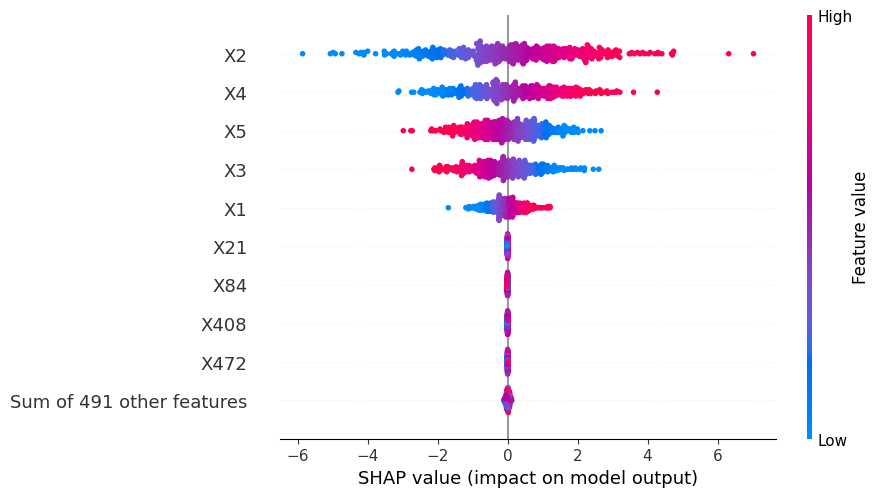

In [ ]:
avg_explanation = shap.Explanation(
    values=avg_shap,
    base_values=avg_base,
    data=X_df.values,
    feature_names=feature_names
)

shap.plots.beeswarm(avg_explanation, max_display=10, show=False)
fig = plt.gcf()
fig.savefig("beeswarm_plot_sparse_high_lasso_linear1.pdf", bbox_inches="tight")
plt.show()